In [6]:
import pandas as pd
import numpy as np

# 1. Load the dataset
df = pd.read_csv('./../data/BostonHousing.csv')

# 2. Look at the first 5 rows and data info
print("--- First 5 Rows ---")
print(df.head())

print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())

--- First 5 Rows ---
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

--- Missing Values Per Column ---
crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [7]:
# Fill missing values in the 'rm' column with its median
df['rm'] = df['rm'].fillna(df['rm'].median())

# Verify that there are no more missing values left
print("--- Missing Values After Cleaning ---")
print(df.isnull().sum())

--- Missing Values After Cleaning ---
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


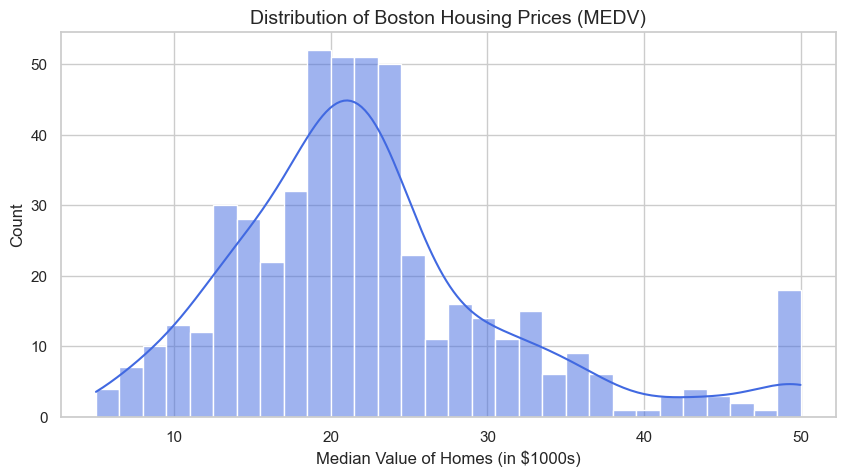

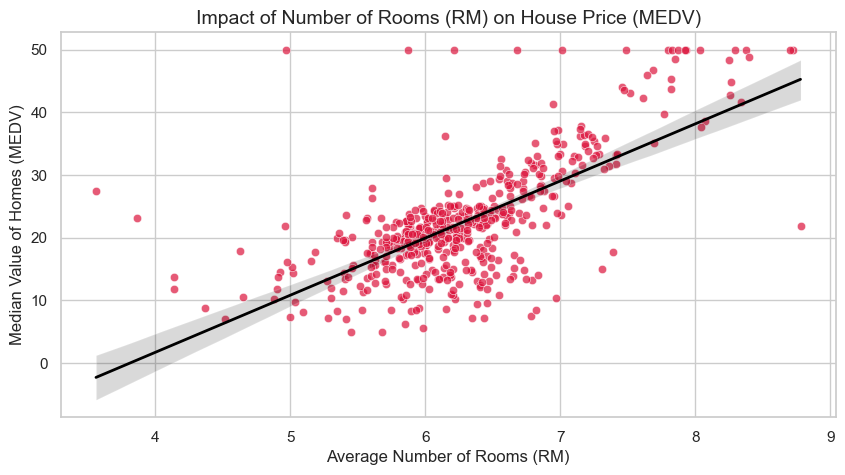

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for clean, professional looking plots
sns.set_theme(style="whitegrid")

# 1. Distribution of Housing Prices (MEDV)
plt.figure(figsize=(10, 5))
sns.histplot(df['medv'], kde=True, color='royalblue', bins=30)
plt.title('Distribution of Boston Housing Prices (MEDV)', fontsize=14)
plt.xlabel('Median Value of Homes (in $1000s)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

# 2. Scatter Plot: Rooms vs Price
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='rm', y='medv', alpha=0.7, color='crimson')
sns.regplot(data=df, x='rm', y='medv', scatter=False, color='black', line_kws={"linewidth": 2})
plt.title('Impact of Number of Rooms (RM) on House Price (MEDV)', fontsize=14)
plt.xlabel('Average Number of Rooms (RM)', fontsize=12)
plt.ylabel('Median Value of Homes (MEDV)', fontsize=12)
plt.show()

In [9]:
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# 1. Remove capped values to prevent model bias
df_filtered = df[df['medv'] < 50.0]

# 2. Separate features (X) and target variable (y)
# We drop 'medv' because that's what we want to predict
X = df_filtered.drop(columns=['medv'])
y = df_filtered['medv']

# 3. Split into 80% Training and 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale features (gives all columns equal weight during training)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Initialize and Train the Ridge Model
model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

# 6. Evaluate Model Performance
predictions = model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("--- Model Performance Metrics ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2 Score (Accuracy Variance): {r2:.2f}")

# 7. Save Cleaned Data and Models for our Dashboard
df_filtered.to_csv('../data/cleaned_housing_data.csv', index=False)

with open('../models/ridge_housing_model.pkl', 'wb') as f:
    pickle.dump(model, f)
    
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\nModel and Scaler artifacts successfully exported to /models/ folder!")

--- Model Performance Metrics ---
Root Mean Squared Error (RMSE): 3.49
R2 Score (Accuracy Variance): 0.76

Model and Scaler artifacts successfully exported to /models/ folder!
